# 🎬 Netflix Data Analysis (1M Records)

## Objective
- Perform EDA on large dataset
- Analyze trends in movies and TV shows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 📊 Data Generation (1 Million Records)

In [2]:
n = 1_000_000

df = pd.DataFrame({
    "Show_ID": np.arange(1, n+1),
    "Title": np.random.choice(["Love Story", "Dark Night", "Money Heist"], n),
    "Type": np.random.choice(["Movie", "TV Show"], n),
    "Genre": np.random.choice(["Drama", "Comedy", "Action"], n),
    "Country": np.random.choice(["India", "USA", "UK"], n),
    "Release_Year": np.random.randint(2000, 2024, n),
    "Rating": np.round(np.random.uniform(1, 10, n), 1),
    "Views_Millions": np.random.uniform(1, 500, n)
})

df.head()

,Show_ID,Title,Type,Genre,Country,Release_Year,Rating,Views_Millions
0,1,Money Heist,TV Show,Drama,UK,2005,3.3,163.683154
1,2,Dark Night,Movie,Comedy,UK,2013,1.2,395.015781
2,3,Money Heist,TV Show,Comedy,USA,2002,2.1,259.630904
3,4,Dark Night,TV Show,Drama,UK,2001,1.4,148.292292
4,5,Dark Night,TV Show,Action,UK,2000,3.0,440.740464


## 💾 Save Dataset

In [3]:
df.to_csv("netflix_1M.csv", index=False)

## 🔍 Data Understanding

In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(1000000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Show_ID         1000000 non-null  int64  
 1   Title           1000000 non-null  object 
 2   Type            1000000 non-null  object 
 3   Genre           1000000 non-null  object 
 4   Country         1000000 non-null  object 
 5   Release_Year    1000000 non-null  int64  
 6   Rating          1000000 non-null  float64
 7   Views_Millions  1000000 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 61.0+ MB
None
              Show_ID    Release_Year          Rating  Views_Millions
count  1000000.000000  1000000.000000  1000000.000000  1000000.000000
mean    500000.500000     2011.508289        5.499025      250.403547
std     288675.278933        6.917940        2.598202      143.987442
min          1.000000     2000.000000        1.000000     

## 🧹 Data Cleaning

In [5]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

## 📈 Exploratory Data Analysis (EDA)

In [6]:
df.groupby("Genre")["Rating"].mean()
df["Type"].value_counts()
df.groupby("Country")["Show_ID"].count()

,Show_ID
Country,
India,333478
UK,333938
USA,332584


## 📊 Visualization

# **Genre distribution**

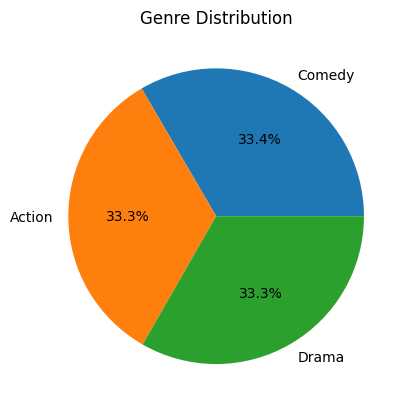

In [7]:
genre_counts = df["Genre"].value_counts()

plt.figure()
genre_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Genre Distribution")
plt.ylabel("")
plt.show()

# **country distribution**

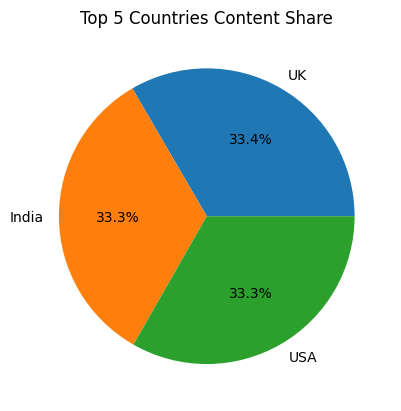

In [8]:
country_counts = df["Country"].value_counts().head(5)

plt.figure()
country_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Top 5 Countries Content Share")
plt.ylabel("")
plt.show()

# **Year-wise content growth**

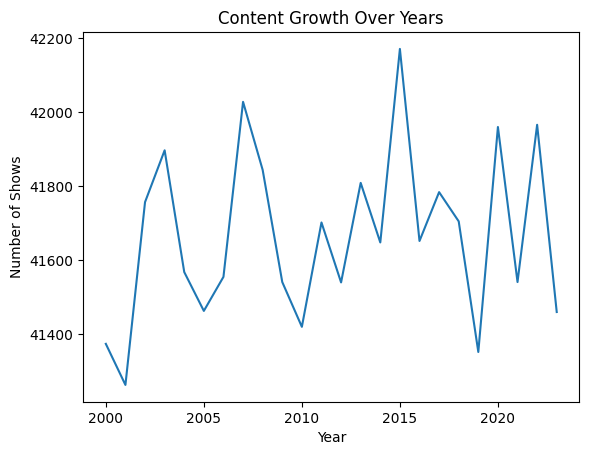

In [9]:
year_data = df.groupby("Release_Year")["Show_ID"].count()

plt.figure()
year_data.plot(kind="line")
plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

# **Average rating over years**

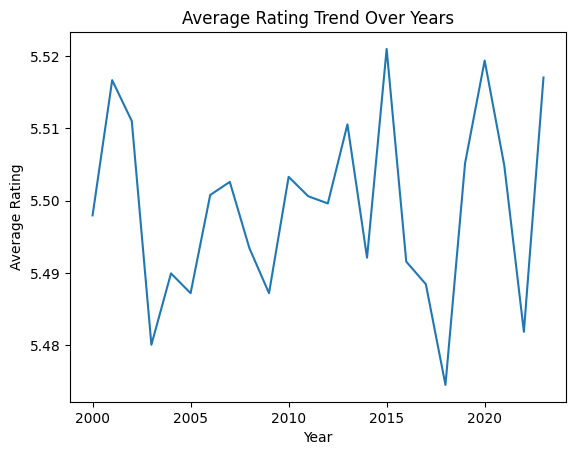

In [10]:
rating_trend = df.groupby("Release_Year")["Rating"].mean()

plt.figure()
rating_trend.plot(kind="line")
plt.title("Average Rating Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

# **Top genres by views**

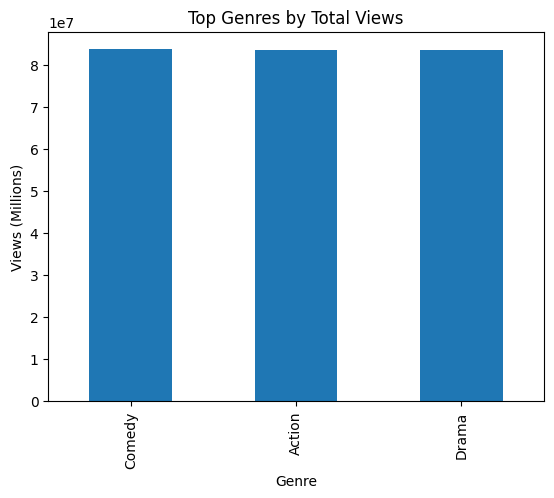

In [11]:
top_genres = df.groupby("Genre")["Views_Millions"].sum().sort_values(ascending=False)

plt.figure()
top_genres.plot(kind="bar")
plt.title("Top Genres by Total Views")
plt.xlabel("Genre")
plt.ylabel("Views (Millions)")
plt.show()

# Rating **distribution**

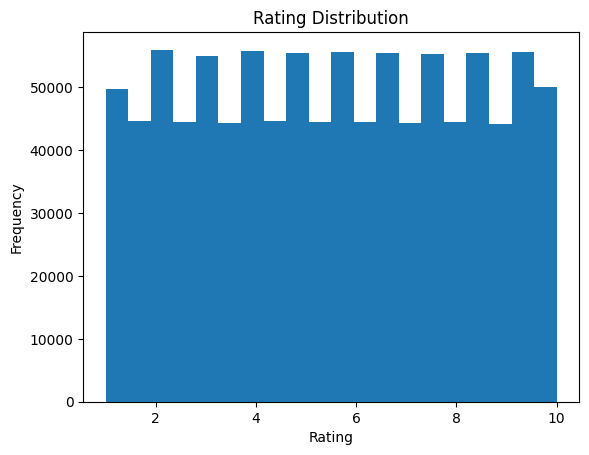

In [12]:
plt.figure()
df["Rating"].plot(kind="hist", bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# **Rating vs views**

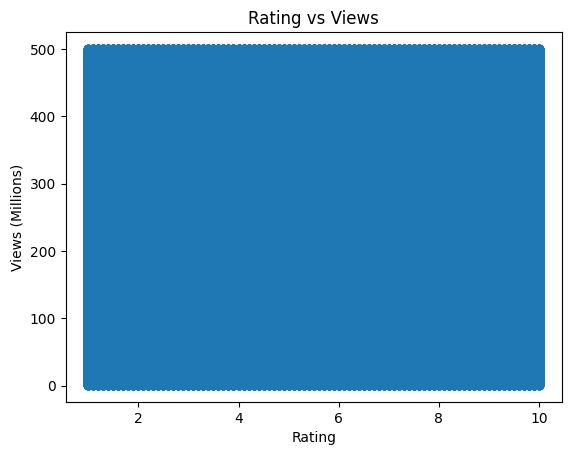

In [13]:
plt.figure()
plt.scatter(df["Rating"], df["Views_Millions"])
plt.title("Rating vs Views")
plt.xlabel("Rating")
plt.ylabel("Views (Millions)")
plt.show()

## 🚀 Advanced Analysis

In [14]:
pd.pivot_table(df, values="Views_Millions", index="Genre", aggfunc="mean")

,Views_Millions
Genre,
Action,250.396663
Comedy,250.289772
Drama,250.524637


## 📌 Conclusion

- Successfully handled 1M dataset
- Performed EDA and visualization
- Extracted meaningful insights